# Merging Normalized Covid19 Data with US Counties Map

In this step, the normalized data before is loaded and merged with US counties map to make maps of US counties daily new cases. Then these map are saved as rasters (images with pixel data) to give the data a more continous characteristic. In a previous effort, the world wide covid cases were analyzed. However, due to the discrete nature of the data the results were not suitable and it was not possible to show spatial patterns. By making image maps, the data becomes more continous and therefore it is possible to extract spatial patterns of disease spread.

In [1]:
import pandas as pd

normalized_covid_data = pd.read_pickle('normalized_covid_data.pkl')

In [2]:
# Convert the dataframe to long format (one row per county and date)
normalized_long = normalized_covid_data.melt(
    id_vars=['FIPS', 'Admin2', 'State', 'Lat', 'Long'], 
    var_name='Date', 
    value_name='Normalized_Cases'
)

# Convert the 'Date' column to a proper datetime format
normalized_long['Date'] = pd.to_datetime(normalized_long['Date'])

# Check the result
print(normalized_long.head())

     FIPS   Admin2    State        Lat       Long       Date  Normalized_Cases
0  1001.0  Autauga  Alabama  32.539527 -86.644082 2020-01-22               0.0
1  1003.0  Baldwin  Alabama  30.727750 -87.722071 2020-01-22               0.0
2  1005.0  Barbour  Alabama  31.868263 -85.387129 2020-01-22               0.0
3  1007.0     Bibb  Alabama  32.996421 -87.125115 2020-01-22               0.0
4  1009.0   Blount  Alabama  33.982109 -86.567906 2020-01-22               0.0


C:\Users\babak\AppData\Local\Temp\ipykernel_6932\1973552539.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  normalized_long['Date'] = pd.to_datetime(normalized_long['Date'])


In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load US counties shapefile
shapefile_path = 'cb_2018_us_county_500k/cb_2018_us_county_500k.shp'
gdf_counties = gpd.read_file(shapefile_path)

# Print the first few rows to inspect the data
print(gdf_counties.head())

  STATEFP COUNTYFP  COUNTYNS        AFFGEOID  GEOID     NAME LSAD       ALAND  \
0      21      007  00516850  0500000US21007  21007  Ballard   06   639387454   
1      21      017  00516855  0500000US21017  21017  Bourbon   06   750439351   
2      21      031  00516862  0500000US21031  21031   Butler   06  1103571974   
3      21      065  00516879  0500000US21065  21065   Estill   06   655509930   
4      21      069  00516881  0500000US21069  21069  Fleming   06   902727151   

     AWATER                                           geometry  
0  69473325  POLYGON ((-89.18137 37.0463, -89.17938 37.0530...  
1   4829777  POLYGON ((-84.44266 38.28324, -84.44114 38.283...  
2  13943044  POLYGON ((-86.94486 37.07341, -86.94346 37.074...  
3   6516335  POLYGON ((-84.12662 37.6454, -84.12483 37.6461...  
4   7182793  POLYGON ((-83.98428 38.44549, -83.98246 38.450...  


In [4]:
# Convert FIPS to string and remove any decimals
normalized_long['FIPS'] = normalized_long['FIPS'].fillna(0).astype(int)

# Similarly, convert GEOID in the counties shapefile to string
gdf_counties['GEOID'] = gdf_counties['GEOID'].astype(int)

In [5]:
# For demonstration, let's choose a date, e.g., '2021-07-01'
covid_day = normalized_long[['FIPS', 'Normalized_Cases', 'Date']].query("Date == '2021-07-01'")

# Merge with the GeoDataFrame using the FIPS code
gdf_merged = gdf_counties.merge(covid_day, how="left", left_on="GEOID", right_on="FIPS")

# Print to check the result
print(gdf_merged.head())

  STATEFP COUNTYFP  COUNTYNS        AFFGEOID  GEOID     NAME LSAD       ALAND  \
0      21      007  00516850  0500000US21007  21007  Ballard   06   639387454   
1      21      017  00516855  0500000US21017  21017  Bourbon   06   750439351   
2      21      031  00516862  0500000US21031  21031   Butler   06  1103571974   
3      21      065  00516879  0500000US21065  21065   Estill   06   655509930   
4      21      069  00516881  0500000US21069  21069  Fleming   06   902727151   

     AWATER                                           geometry     FIPS  \
0  69473325  POLYGON ((-89.18137 37.0463, -89.17938 37.0530...  21007.0   
1   4829777  POLYGON ((-84.44266 38.28324, -84.44114 38.283...  21017.0   
2  13943044  POLYGON ((-86.94486 37.07341, -86.94346 37.074...  21031.0   
3   6516335  POLYGON ((-84.12662 37.6454, -84.12483 37.6461...  21065.0   
4   7182793  POLYGON ((-83.98428 38.44549, -83.98246 38.450...  21069.0   

   Normalized_Cases       Date  
0      54637.700013 2021-07-0

C:\Users\babak\AppData\Local\Temp\ipykernel_6932\3153577757.py:2: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  covid_day = normalized_long[['FIPS', 'Normalized_Cases', 'Date']].query("Date == '2021-07-01'")


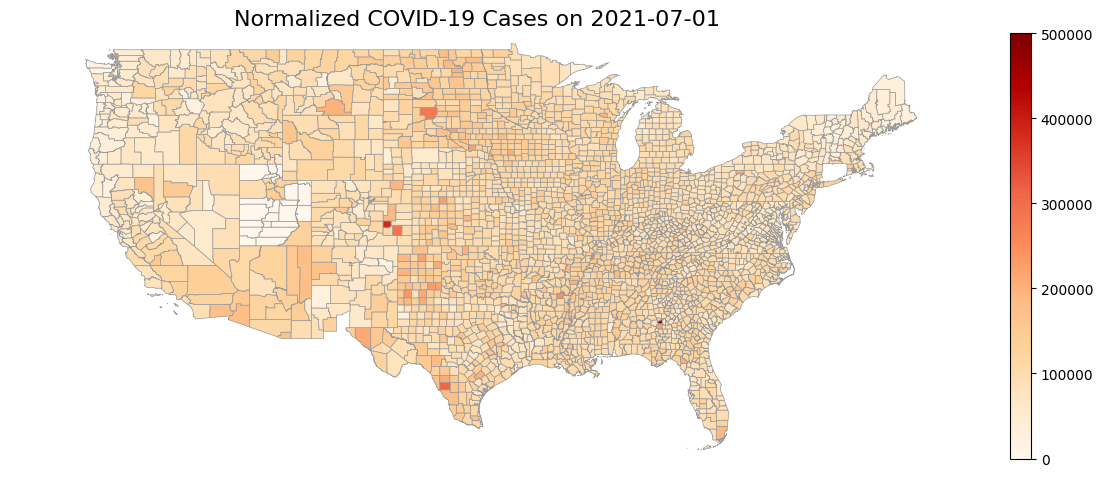

In [6]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Increase figure size and aspect ratio
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# Plot with better scaling
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="2%", pad=0.01)  # Adjust the size and padding of the color bar

gdf_merged.plot(column='Normalized_Cases', cmap='OrRd', linewidth=0.5, edgecolor='0.6', legend=True, ax=ax, cax=cax)

# Adjust plot limits to fit the continental US
ax.set_xlim([-130, -65])
ax.set_ylim([24, 50])

# Customize the plot - Title and remove axis for a cleaner look
ax.set_title("Normalized COVID-19 Cases on 2021-07-01", fontsize=16)
ax.axis('off')  # Remove axis for a cleaner map

# Show the plot
plt.show()

In [7]:
# Convert coordinate system from latitude and longitude (degrees) ...
# to the to USGS Contiguous US Albers Equal Area, EPSG:5070 (This is metric system)
gdf_counties_reprojected = gdf_counties.to_crs(epsg=5070)

In [8]:
counties_covid_data = normalized_long[['FIPS', 'Normalized_Cases', 'Date']]

# Merge with the GeoDataFrame using the FIPS code
gdf_counties_covid_data = gdf_counties_reprojected.merge(counties_covid_data, how="left", left_on="GEOID", right_on="FIPS")

# Print to check the result
print(gdf_counties_covid_data.head())

  STATEFP COUNTYFP  COUNTYNS        AFFGEOID  GEOID     NAME LSAD      ALAND  \
0      21      007  00516850  0500000US21007  21007  Ballard   06  639387454   
1      21      007  00516850  0500000US21007  21007  Ballard   06  639387454   
2      21      007  00516850  0500000US21007  21007  Ballard   06  639387454   
3      21      007  00516850  0500000US21007  21007  Ballard   06  639387454   
4      21      007  00516850  0500000US21007  21007  Ballard   06  639387454   

     AWATER                                           geometry     FIPS  \
0  69473325  POLYGON ((600246.776 1577487.744, 600367.325 1...  21007.0   
1  69473325  POLYGON ((600246.776 1577487.744, 600367.325 1...  21007.0   
2  69473325  POLYGON ((600246.776 1577487.744, 600367.325 1...  21007.0   
3  69473325  POLYGON ((600246.776 1577487.744, 600367.325 1...  21007.0   
4  69473325  POLYGON ((600246.776 1577487.744, 600367.325 1...  21007.0   

   Normalized_Cases       Date  
0               0.0 2020-01-22  
1 

In [9]:
counties_day = gdf_counties_covid_data.query("Date == '2021-07-01'")

C:\Users\babak\AppData\Local\Temp\ipykernel_6932\1340732534.py:1: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  counties_day = gdf_counties_covid_data.query("Date == '2021-07-01'")


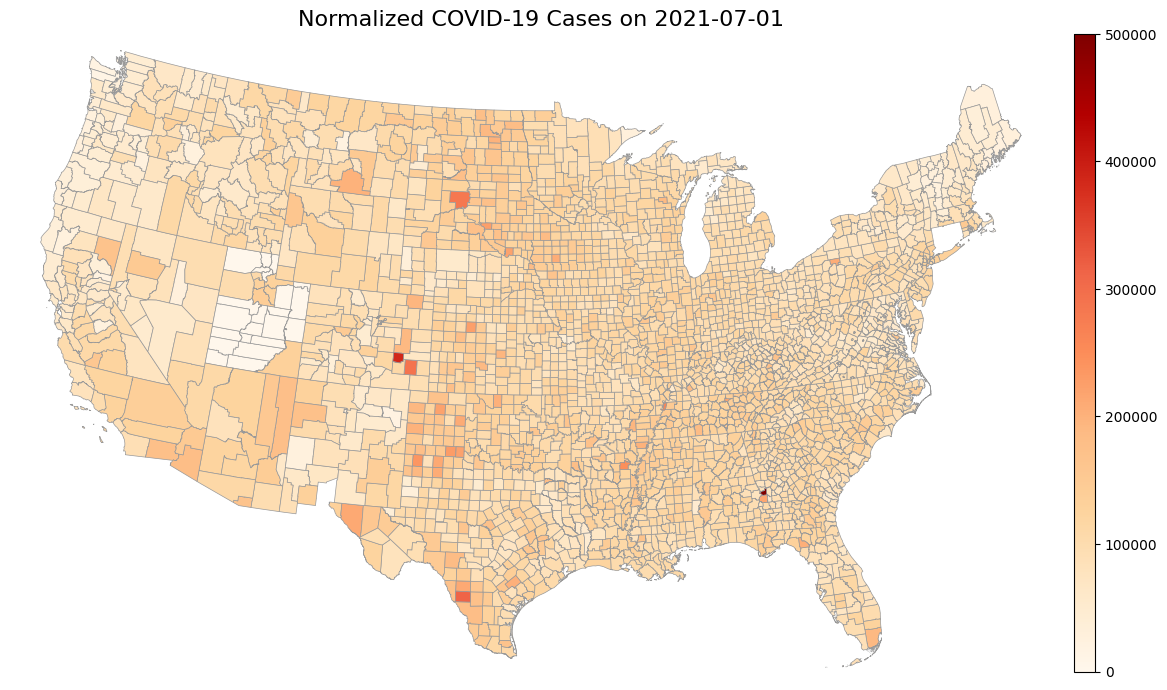

In [10]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Increase figure size and aspect ratio
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# Plot with better scaling
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="2%", pad=0.01)  # Adjust the size and padding of the color bar

counties_day.plot(column='Normalized_Cases', cmap='OrRd', linewidth=0.5, edgecolor='0.6', legend=True, ax=ax, cax=cax)

# Adjust plot limits to fit the continental US
ax.set_xlim([-2500000, 2500000])
ax.set_ylim([250000, 3250000])

# Customize the plot - Title and remove axis for a cleaner look
ax.set_title("Normalized COVID-19 Cases on 2021-07-01", fontsize=16)
ax.axis('off')  # Remove axis for a cleaner map

# Show the plot
plt.show()

In [11]:
import rasterio
from rasterio.features import rasterize
import numpy as np

# Define the resolution and bounds for the raster (10km cells)
resolution = 10000  # 10 km = 10000 meters

# Get the bounding box of the entire dataset to create the grid
minx, miny, maxx, maxy = gdf_counties_covid_data.total_bounds

# Define raster dimensions (number of rows and columns)
rows = int((maxy - miny) / resolution)
cols = int((maxx - minx) / resolution)

# Create the transform for the raster
transform = rasterio.transform.from_bounds(minx, miny, maxx, maxy, cols, rows)

# Loop over each day in the dataset
dates = gdf_counties_covid_data['Date'].unique()
#dates = dates[1]

In [12]:
for date in dates:
    # Filter the GeoDataFrame for the current date
    gdf_date = gdf_counties_covid_data[gdf_counties_covid_data['Date'] == date]

    # Create a generator of (geometry, value) pairs for the rasterize function
    shapes_and_values = ((geom, value) for geom, value in zip(gdf_date.geometry, gdf_date['Normalized_Cases']))

    # Rasterize the shapes, filling in with the values for Normalized_Cases
    raster = rasterize(
        shapes_and_values,
        out_shape=(rows, cols),
        transform=transform,
        fill=np.nan,  # Fill missing areas with NaN
        all_touched=True,  # Ensures that partially covered pixels are included
        dtype='float64'
    )

    # Save the raster as a GeoTIFF file
    folder_name = "raster_files"

    # Keep only the date part (YYYY-MM-DD)
    date_str = date.strftime('%Y-%m-%d')  # Format as 'YYYY-MM-DD'
    output_path = f"{folder_name}/covid_raster_{date_str}.tif"
    with rasterio.open(
        output_path, 'w',
        driver='GTiff',
        height=rows,
        width=cols,
        count=1,  # Number of bands
        dtype='float64',
        crs=gdf_counties_reprojected.crs,  # Use the CRS from the GeoDataFrame
        transform=transform
    ) as dst:
        dst.write(raster, 1)

    print(f"Raster for {date} saved at {output_path}")

Raster for 2020-01-22 00:00:00 saved at raster_files/covid_raster_2020-01-22.tif
Raster for 2020-01-23 00:00:00 saved at raster_files/covid_raster_2020-01-23.tif
Raster for 2020-01-24 00:00:00 saved at raster_files/covid_raster_2020-01-24.tif
Raster for 2020-01-25 00:00:00 saved at raster_files/covid_raster_2020-01-25.tif
Raster for 2020-01-26 00:00:00 saved at raster_files/covid_raster_2020-01-26.tif
Raster for 2020-01-27 00:00:00 saved at raster_files/covid_raster_2020-01-27.tif
Raster for 2020-01-28 00:00:00 saved at raster_files/covid_raster_2020-01-28.tif
Raster for 2020-01-29 00:00:00 saved at raster_files/covid_raster_2020-01-29.tif
Raster for 2020-01-30 00:00:00 saved at raster_files/covid_raster_2020-01-30.tif
Raster for 2020-01-31 00:00:00 saved at raster_files/covid_raster_2020-01-31.tif
Raster for 2020-02-01 00:00:00 saved at raster_files/covid_raster_2020-02-01.tif
Raster for 2020-02-02 00:00:00 saved at raster_files/covid_raster_2020-02-02.tif
Raster for 2020-02-03 00:00:

ValueError: NaTType does not support strftime